# ***PART 1 - ENVIRONMENTAL SETUP***

In [1]:
!pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.0 MB/s eta 0:00:00


# ***PART 2 - Heart Disease Dataset***

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wfdb

from PIL import Image
from collections import Counter

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
    "age", "sex", "cp", "trestbps", "chol",
    "fbs", "restecg", "thalach", "exang",
    "oldpeak", "slope", "ca", "thal", "target"
]
df = pd.read_csv(url, names=columns)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
#CHECK DATASET
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape: (303, 14)

Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB

In [5]:
# checking missing values
df = df.replace("?", np.nan)

print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [6]:
# removing missing values
df = df.dropna()

print("New Shape:", df.shape)

New Shape: (297, 14)


In [7]:
# convert columns to numbers
df = df.apply(pd.to_numeric)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [8]:
# Convert target into 0 = No Heart Disease 1 = Heart Disease

df["target"] = (df["target"] > 0).astype(int)

df["target"].value_counts()

,count
target,
0,160
1,137


In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


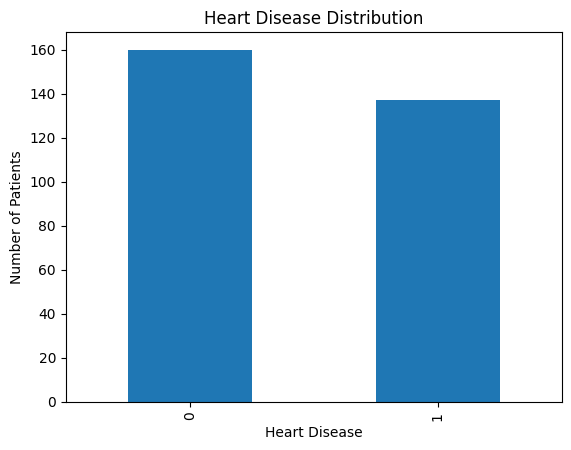

In [10]:
# visualization
df["target"].value_counts().plot(kind="bar")

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.show()

***LOGISTIC REGRESSING***

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [13]:
# Prediction and accuracy
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8833333333333333


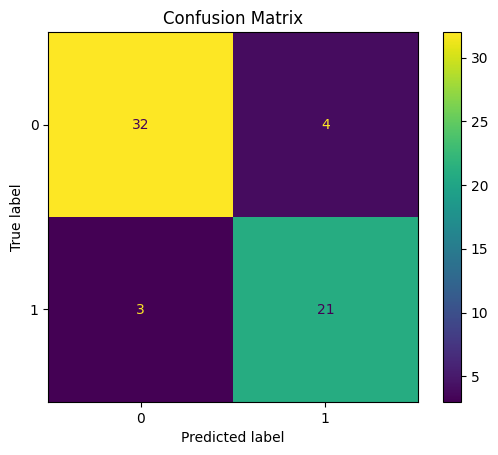

In [14]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()

plt.title("Confusion Matrix")
plt.show()

# ***PART 3 — ECG SIGNAL DATA***

In [16]:
record = wfdb.rdrecord(
    "100",
    pn_dir="mitdb"
)

print(record)
signal = record.p_signal

print("Signal Shape:", signal.shape)

print(signal[:10])

Signal Shape: (650000, 2)
[[-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.12  -0.08 ]
 [-0.135 -0.08 ]]


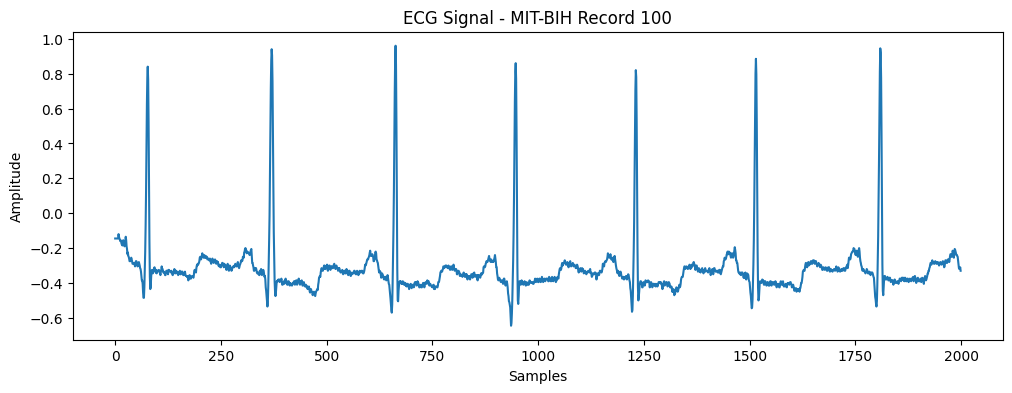

In [17]:
#Plot ECG signal
plt.figure(figsize=(12, 4))

plt.plot(signal[:2000, 0])

plt.title("ECG Signal - MIT-BIH Record 100")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

In [18]:
annotation = wfdb.rdann(
    "100",
    "atr",
    pn_dir="mitdb"
)

print("Number of annotations:", len(annotation.sample))

print("First annotations:")
print(annotation.symbol[:20])

Number of annotations: 2274
First annotations:
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


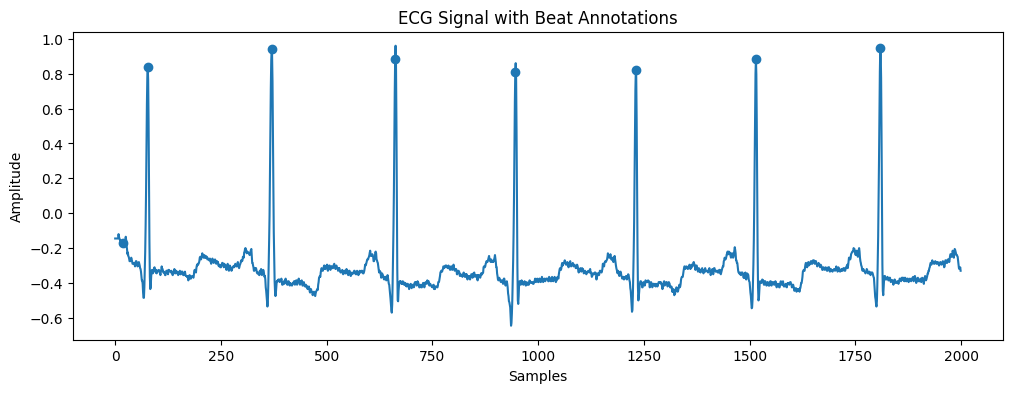

In [19]:
#ECG with beat positions
plt.figure(figsize=(12, 4))

plt.plot(signal[:2000, 0])

beats = annotation.sample
beats = beats[beats < 2000]

plt.scatter(
    beats,
    signal[beats, 0]
)

plt.title("ECG Signal with Beat Annotations")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

In [20]:
#Calculate average heart rate
beat_samples = annotation.sample

rr_intervals = np.diff(beat_samples)

sampling_rate = record.fs

rr_seconds = rr_intervals / sampling_rate

heart_rates = 60 / rr_seconds

print("Average Heart Rate:", heart_rates.mean(), "BPM")

Average Heart Rate: 75.94458550403931 BPM


# ***PART 4 — TEXTUAL DATA***

In [25]:
#Create sample medical text
text = """
Patient is a 55 year old male.
Patient reports chest pain and shortness of breath.
Blood pressure is high.
The patient has a history of hypertension.
"""

print(text)


Patient is a 55 year old male.
Patient reports chest pain and shortness of breath.
Blood pressure is high.
The patient has a history of hypertension.



In [27]:
#Simple tokenization
words = text.lower().split()
print(words)

# Word frequency
word_frequency = Counter(words)
print("word_frequency: ", word_frequency)

#Most common words
print("common words: " , word_frequency.most_common(10))

['patient', 'is', 'a', '55', 'year', 'old', 'male.', 'patient', 'reports', 'chest', 'pain', 'and', 'shortness', 'of', 'breath.', 'blood', 'pressure', 'is', 'high.', 'the', 'patient', 'has', 'a', 'history', 'of', 'hypertension.']
word_frequency:  Counter({'patient': 3, 'is': 2, 'a': 2, 'of': 2, '55': 1, 'year': 1, 'old': 1, 'male.': 1, 'reports': 1, 'chest': 1, 'pain': 1, 'and': 1, 'shortness': 1, 'breath.': 1, 'blood': 1, 'pressure': 1, 'high.': 1, 'the': 1, 'has': 1, 'history': 1, 'hypertension.': 1})
common words:  [('patient', 3), ('is', 2), ('a', 2), ('of', 2), ('55', 1), ('year', 1), ('old', 1), ('male.', 1), ('reports', 1), ('chest', 1)]


# ***5. Image Data Demonstration***

Image loaded successfully


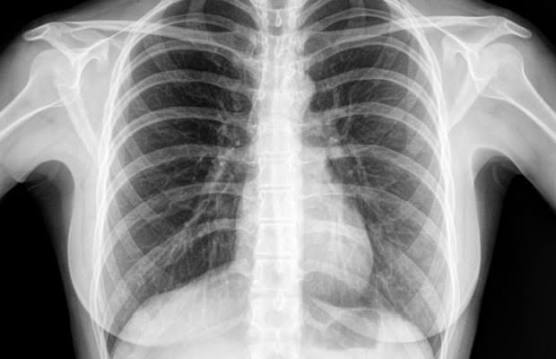

In [30]:
#Import Pillow
from PIL import Image

#Load the X-ray image
image = Image.open("lab1 chest xray.jpg")

print("Image loaded successfully")
display(image)

Format: JPEG
Size: (556, 359)
Mode: RGB
New Size: (224, 224)


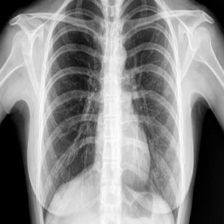

In [32]:
#Extract image information
print("Format:", image.format)
print("Size:", image.size)
print("Mode:", image.mode)

#Resize the image
resized_image = image.resize((224, 224))
print("New Size:", resized_image.size)

#Display resized image
display(resized_image)